In [1]:
import xarray as xr
import pandas as pd
import os
import numpy as np

In [2]:
ds_input = xr.open_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1.zarr")
boundary = xr.open_zarr("/pscratch/sd/a/asubel/Plots_For_Neurips/hfds_anomalies.zarr")
ds_input["hfds_anomalies"] = boundary["hfds"]
levels=19

In [9]:
years = 100
window = 10
dates = np.array(range(3, 365*years, 5))
repeats = years // window

ds_groundtruth = ds_input.isel(lev=slice(None, levels))

# Strong El Nino
start_year = 1990
reduce_by = .017462726
ds_groundtruth = ds_groundtruth.sel(time=slice("1990-01-01", "1999-12-31")) # 10 years

# Moderately strong EN and LN
# start_year = 2002
# reduce_by = 0.267875653
# ds_groundtruth = ds_groundtruth.sel(time=slice("2002-01-01", "2011-12-31")) # 10 years

# Strong La Nina
# start_year = 1998
# reduce_by = 0.31751058995
# ds_groundtruth = ds_groundtruth.sel(time=slice("1998-01-01", "2007-12-31")) # 10 years

In [8]:
# No CC
# new_time = np.array([np.datetime64('1996') + np.timedelta64(day-1,'D') for day in dates])
# for i in range(1,repeats):
#     new_time = np.hstack((new_time,np.array([np.datetime64(str(1996+i)) + np.timedelta64(day-1,'D') for day in dates])))
# ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
# ds_groundtruth['time'] = new_time[:7300]

In [157]:
# Net Zero HF
new_time = np.array([np.datetime64(str(start_year)) + np.timedelta64(day-1,'D') for day in dates])
for i in range(1,repeats):
    new_time = np.hstack((new_time,np.array([np.datetime64(str(start_year+i)) + np.timedelta64(day-1,'D') for day in dates])))
ds_groundtruth['hfds'] = ds_groundtruth['hfds'] - reduce_by
ds_groundtruth['hfds_anomalies'] = ds_groundtruth['hfds_anomalies'] - reduce_by
ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
ds_groundtruth['time'] = new_time[:7300]

/tmp/ipykernel_1278444/2627207901.py:8: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_groundtruth['time'] = new_time[:7300]
/tmp/ipykernel_1278444/2627207901.py:8: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanos

In [ ]:
# CC 1 with Netzero hf
new_time = np.array([np.datetime64(str(start_year)) + np.timedelta64(day-1,'D') for day in dates])
for i in range(1,repeats):
    new_time = np.hstack((new_time,np.array([np.datetime64(str(start_year+i)) + np.timedelta64(day-1,'D') for day in dates])))
# new_time = pd.date_range(start=str(ds_groundtruth.time[0].values), periods=repeats * len(ds_groundtruth.time), freq="5D")
ds_groundtruth['hfds'] = ds_groundtruth['hfds'] - reduce_by
ds_groundtruth['hfds_anomalies'] = ds_groundtruth['hfds_anomalies'] - reduce_by    
ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
ds_groundtruth['hfds'] = ds_groundtruth['hfds'] + np.reshape(np.arange(ds_groundtruth.time.size)*4.01369026e-04,(-1,1,1))
ds_groundtruth['hfds_anomalies'] = ds_groundtruth['hfds_anomalies'] + np.reshape(np.arange(ds_groundtruth.time.size)*4.01369026e-04,(-1,1,1))
ds_groundtruth['time'] = new_time[:7300]

In [41]:
# # CC 2
# new_time = np.array([np.datetime64(str(start_year)) + np.timedelta64(day-1,'D') for day in dates])
# for i in range(1,repeats):
#     new_time = np.hstack((new_time,np.array([np.datetime64(str(start_year+i)) + np.timedelta64(day-1,'D') for day in dates])))
# # new_time = pd.date_range(start=str(ds_groundtruth.time[0].values), periods=repeats * len(ds_groundtruth.time), freq="5D")
# ds_groundtruth['hfds'] = ds_groundtruth['hfds'] - .12086974
# ds_groundtruth['hfds_anomalies'] = ds_groundtruth['hfds_anomalies'] - .12086974    
# ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
# ds_groundtruth['hfds'] = ds_groundtruth['hfds'] + np.reshape(2 + np.arange(ds_groundtruth.time.size)*15e-04,(-1,1,1))
# ds_groundtruth['hfds_anomalies'] = ds_groundtruth['hfds_anomalies'] + np.reshape(2 + np.arange(ds_groundtruth.time.size)*15e-04,(-1,1,1))
# ds_groundtruth['time'] = new_time[:7300]

/tmp/ipykernel_1040808/3580874445.py:11: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_groundtruth['time'] = new_time[:7300]
/tmp/ipykernel_1040808/3580874445.py:11: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nan

In [47]:
# CC 3
# new_time = np.array([np.datetime64(str(start_year)) + np.timedelta64(day-1,'D') for day in dates])
# for i in range(1,repeats):
#     new_time = np.hstack((new_time,np.array([np.datetime64(str(start_year+i)) + np.timedelta64(day-1,'D') for day in dates])))
# # new_time = pd.date_range(start=str(ds_groundtruth.time[0].values), periods=repeats * len(ds_groundtruth.time), freq="5D")
# ds_groundtruth['hfds'] = ds_groundtruth['hfds'] - .12086974
# ds_groundtruth['hfds_anomalies'] = ds_groundtruth['hfds_anomalies'] - .12086974    
# ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
# ds_groundtruth['hfds'] = ds_groundtruth['hfds'] + np.reshape(2 + np.arange(ds_groundtruth.time.size)*75e-04,(-1,1,1))
# ds_groundtruth['hfds_anomalies'] = ds_groundtruth['hfds_anomalies'] + np.reshape(2 + np.arange(ds_groundtruth.time.size)*75e-04,(-1,1,1))
# ds_groundtruth['time'] = new_time[:7300]

/tmp/ipykernel_1040808/3921278580.py:11: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_groundtruth['time'] = new_time[:7300]
/tmp/ipykernel_1040808/3921278580.py:11: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nan

In [158]:
ds_groundtruth

<xarray.Dataset>
Dimensions:         (y: 180, x: 360, lev: 19, time: 7300, y_b: 181, x_b: 361)
Coordinates:
    areacello       (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz              (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
  * lev             (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    ocean_fraction  (lev, y, x) float64 dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
  * time            (time) datetime64[ns] 1998-01-03 1998-01-08 ... 2097-12-04
    wetmask         (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x               (x) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
Dimensions without coordinates: y_b, x_b
Data variables:
    hfds            (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    tauuo           (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    tauvo           (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    thetao          (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    uo              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    vo              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    zos             (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    hfds_anomalies  (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [159]:
from dask.diagnostics import ProgressBar
with ProgressBar():
    ds_groundtruth.to_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1_with_hfds_anom_100_years_10repeat_1998_netzerohf")

[########################################] | 100% Completed | 70.41 s


#### Testing Net zero heatflux

<xarray.DataArray 'polyfit_coefficients' (degree: 2)>
array([ 5.85776263e-04, -5.81110659e+14])
Coordinates:
  * degree   (degree) int64 1 0
<xarray.DataArray 'polyfit_coefficients' (degree: 2)>
array([ 5.85776270e-04, -6.81643727e+14])
Coordinates:
  * degree   (degree) int64 1 0


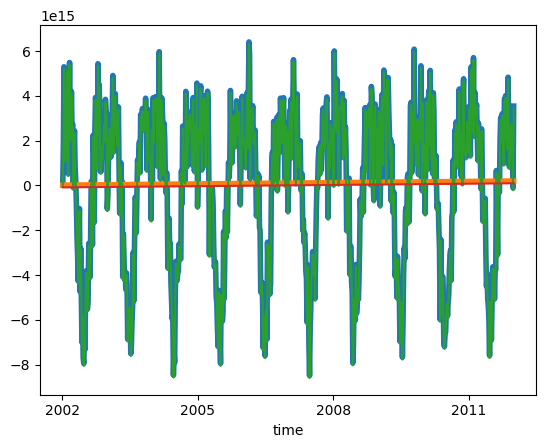

In [5]:
var = 'hfds' # hfds, hfds_anomalies

hfs_true = ds_groundtruth[var]
total_heat_flux = (hfs_true*ds_groundtruth['areacello']).sum(['x','y'])

poly_coeffs = total_heat_flux.polyfit(dim='time', deg=1)
trend = xr.polyval(ds_groundtruth['time'], poly_coeffs.polyfit_coefficients)
print(poly_coeffs.polyfit_coefficients.load())

total_heat_flux.plot(lw=4)
trend.plot(lw=4)

# After reduction
hfs_true = ds_groundtruth[var] - reduce_by
total_heat_flux = (hfs_true*ds_groundtruth['areacello']).sum(['x','y'])

poly_coeffs = total_heat_flux.polyfit(dim='time', deg=1)
trend = xr.polyval(ds_groundtruth['time'], poly_coeffs.polyfit_coefficients)
print(poly_coeffs.polyfit_coefficients.load())

total_heat_flux.plot()
trend.plot()

In [10]:
data = ds_groundtruth
heat_added = 464318398136123
cur_reduce_by = 0
while np.log10(heat_added) > 0:
    hfs_true = data['hfds'] - cur_reduce_by
    total_heat_flux = (hfs_true*data['areacello']).sum(['x','y'])
    heat_added = np.trapz(total_heat_flux.values)
    # print(heat_added)
    print(np.log10(heat_added))
    watt_to_remove = (heat_added/data['areacello'].sum(['x','y']))/(data.time.size)
    print(watt_to_remove.load())
    cur_reduce_by += watt_to_remove.load()
    print("cur reduce by:",  cur_reduce_by)
    

15.679202982398788
<xarray.DataArray 'areacello' ()>
array(0.01289147)
cur reduce by: <xarray.DataArray 'areacello' ()>
array(0.01289147)
15.097087985196124
<xarray.DataArray 'areacello' ()>
array(0.00337433)
cur reduce by: <xarray.DataArray 'areacello' ()>
array(0.0162658)
14.514972987992888
<xarray.DataArray 'areacello' ()>
array(0.00088323)
cur reduce by: <xarray.DataArray 'areacello' ()>
array(0.01714903)
13.932857990793272
<xarray.DataArray 'areacello' ()>
array(0.00023118)
cur reduce by: <xarray.DataArray 'areacello' ()>
array(0.01738021)
13.350742993577876
<xarray.DataArray 'areacello' ()>
array(6.05121373e-05)
cur reduce by: <xarray.DataArray 'areacello' ()>
array(0.01744072)
12.768627996368535
<xarray.DataArray 'areacello' ()>
array(1.58389904e-05)
cur reduce by: <xarray.DataArray 'areacello' ()>
array(0.01745656)
12.186512999342717
<xarray.DataArray 'areacello' ()>
array(4.14583963e-06)
cur reduce by: <xarray.DataArray 'areacello' ()>
array(0.01746071)
11.604398002006006
<xar

/tmp/ipykernel_612059/2840676983.py:9: RuntimeWarning: invalid value encountered in log10
  print(np.log10(heat_added))
/tmp/ipykernel_612059/2840676983.py:4: RuntimeWarning: invalid value encountered in log10
  while np.log10(heat_added) > 0:


In [13]:
data['areacello'].shape

(180, 360)

In [16]:
data = ds_groundtruth
hfs_true = data['hfds'] - .017462726
# area = data['areacello']/data['areacello'].max()
total_heat_flux = (hfs_true*data['areacello']).sum(['x','y'])
heat_added = np.trapz(total_heat_flux.values)
print(heat_added)
print(np.log10(heat_added))
watt_to_remove = (heat_added/data['areacello'].sum(['x','y']))/(data.time.size)
print(watt_to_remove.load())

-27486493553600.0
nan
<xarray.DataArray 'areacello' ()>
array(-7.41683879e-05)


/tmp/ipykernel_612059/1921500772.py:7: RuntimeWarning: invalid value encountered in log10
  print(np.log10(heat_added))


In [8]:
1/data.time.size

0.0013698630136986301